In [1]:
!pip install opencv-python scikit-learn matplotlib seaborn tqdm

import numpy as np
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import os
from pathlib import Path
import pickle
from tqdm import tqdm

In [2]:
DATA_DIR = '../data'
IMG_SIZE = (64, 64)
MODEL_TYPE = 'random_forest'
CLASS_NAMES = ['galaxy', 'nebula', 'planet', 'star', 'unknown']

print(f"Configuration:")
print(f"  Data directory: {DATA_DIR}")
print(f"  Image size: {IMG_SIZE}")
print(f"  Model type: {MODEL_TYPE}")
print(f"  Classes: {CLASS_NAMES}")

Configuration:
  Data directory: ../data
  Image size: (64, 64)
  Model type: random_forest
  Classes: ['galaxy', 'nebula', 'planet', 'star', 'unknown']


In [3]:
def extract_features(img_path, img_size=IMG_SIZE):
    """
    Extract hand-crafted features from an image.
    
    Features include:
    - Color histograms (RGB and HSV)
    - Texture features (gradient statistics)
    - Edge density
    - Intensity statistics
    """
    # Read and resize image
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")
    
    img = cv2.resize(img, img_size)
    
    # Convert to different color spaces
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    features = []
    
    # 1. Color histograms (RGB) - 32 bins per channel
    for i in range(3):
        hist = cv2.calcHist([img], [i], None, [32], [0, 256])
        features.extend(hist.flatten())
    
    # 2. HSV histograms - 32 bins per channel
    for i in range(3):
        hist = cv2.calcHist([hsv], [i], None, [32], [0, 256])
        features.extend(hist.flatten())
    
    # 3. Grayscale histogram
    hist_gray = cv2.calcHist([gray], [0], None, [32], [0, 256])
    features.extend(hist_gray.flatten())
    
    # 4. Texture features (gradient-based)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    gradient_mag = np.sqrt(sobelx**2 + sobely**2)
    
    features.extend([
        np.mean(gradient_mag),
        np.std(gradient_mag),
        np.max(gradient_mag),
        np.min(gradient_mag)
    ])
    
    # 5. Edge density
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size
    features.append(edge_density)
    
    # 6. Intensity statistics
    features.extend([
        np.mean(gray),
        np.std(gray),
        np.median(gray),
        np.max(gray),
        np.min(gray)
    ])
    
    # 7. Overall brightness variation
    features.append(np.std(img.flatten()))
    
    # 8. Center brightness (stars tend to be bright in center)
    center_region = gray[
        img_size[1]//4:3*img_size[1]//4,
        img_size[0]//4:3*img_size[0]//4
    ]
    features.extend([
        np.mean(center_region),
        np.max(center_region)
    ])
    
    return np.array(features)

print("Feature extraction function defined!")
print(f"Total features extracted per image: ~{32*7 + 13}")

Feature extraction function defined!
Total features extracted per image: ~237


In [4]:
def load_data(data_dir, split='train', class_names=CLASS_NAMES):
    """Load images and extract features from directory structure."""
    data_path = Path(data_dir) / split
    X = []
    y = []
    
    print(f"\nLoading {split} data from {data_path}...")
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = data_path / class_name
        if not class_dir.exists():
            print(f"Warning: {class_dir} does not exist, skipping...")
            continue
        
        image_files = list(class_dir.glob('*.png')) + \
                     list(class_dir.glob('*.jpg')) + \
                     list(class_dir.glob('*.jpeg'))
        
        print(f"  {class_name}: {len(image_files)} images")
        
        for img_path in tqdm(image_files, desc=f"  Processing {class_name}"):
            try:
                features = extract_features(img_path)
                X.append(features)
                y.append(class_idx)
            except Exception as e:
                print(f"    Error processing {img_path}: {e}")
                continue
    
    X = np.array(X)
    y = np.array(y)
    
    print(f"\n{split.upper()} SET SUMMARY:")
    print(f"  Total samples: {len(X)}")
    print(f"  Feature dimensions: {X.shape[1]}")
    print(f"  Class distribution: {dict(zip(class_names, np.bincount(y)))}")
    
    return X, y

print("Data loading function defined!")

Data loading function defined!


In [5]:
print("TRAINING DATA")
X_train, y_train = load_data(DATA_DIR, 'train')

TRAINING DATA

Loading train data from ..\data\train...
  galaxy: 28512 images


  Processing galaxy: 100%|█████████████████████████████████████████████████████| 28512/28512 [1:30:19<00:00,  5.26it/s]


  nebula: 1223 images


  Processing nebula:  15%|████████▊                                                 | 185/1223 [00:02<00:14, 73.62it/s]

    Error processing ..\data\train\nebula\Nebula0194.jpg: Could not read image: ..\data\train\nebula\Nebula0194.jpg


...

  star: 36 images


  Processing star: 100%|██████████████████████████████████████████████████████████████| 36/36 [00:00<00:00, 109.08it/s]


  unknown: 1689 images


  Processing unknown: 100%|████████████████████████████████████████████████████████| 1689/1689 [00:17<00:00, 98.11it/s]



TRAIN SET SUMMARY:
  Total samples: 92259
  Feature dimensions: 237
  Class distribution: {'galaxy': np.int64(28512), 'nebula': np.int64(1221), 'planet': np.int64(60801), 'star': np.int64(36), 'unknown': np.int64(1689)}


In [6]:
print("TEST DATA")
X_test, y_test = load_data(DATA_DIR, 'test')

TEST DATA

Loading test data from ..\data\test...
  galaxy: 108 images


  Processing galaxy: 100%|██████████████████████████████████████████████████████████| 108/108 [00:00<00:00, 142.34it/s]


  nebula: 1574 images


  Processing nebula:  12%|██████▊                                                   | 186/1574 [00:35<04:51,  4.77it/s]

    Error processing ..\data\test\nebula\Nebula0194.jpg: Could not read image: ..\data\test\nebula\Nebula0194.jpg


...

  star: 0 images


  Processing star: 0it [00:00, ?it/s]


  unknown: 347 images


  Processing unknown: 100%|██████████████████████████████████████████████████████████| 347/347 [00:04<00:00, 71.96it/s]


TEST SET SUMMARY:
  Total samples: 2669
  Feature dimensions: 237
  Class distribution: {'galaxy': np.int64(108), 'nebula': np.int64(1571), 'planet': np.int64(643), 'star': np.int64(0), 'unknown': np.int64(347)}


In [17]:
def visualize_samples(data_dir, class_names=CLASS_NAMES, samples_per_class=3):
    """Visualize sample images from each class."""
    fig, axes = plt.subplots(len(class_names), samples_per_class, 
                             figsize=(12, 10))
    
    for class_idx, class_name in enumerate(class_names):
        class_dir = Path(data_dir) / 'train' / class_name
        if not class_dir.exists():
            continue
        
        image_files = list(class_dir.glob('*.png'))[:samples_per_class]
        
        for img_idx, img_path in enumerate(image_files):
            img = cv2.imread(str(img_path))
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            ax = axes[class_idx, img_idx]
            ax.imshow(img_rgb)
            ax.axis('off')
            if img_idx == 0:
                ax.set_title(f"{class_name}", fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


In [18]:
print("Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled")

Scaling features...
Features scaled


In [19]:
print("TRAINING MODEL")
if MODEL_TYPE == 'random_forest':
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
elif MODEL_TYPE == 'svm':
    model = SVC(
        kernel='rbf',
        C=10.0,
        gamma='scale',
        random_state=42,
        probability=True,
        verbose=True
    )
else:
    raise ValueError("MODEL_TYPE must be 'random_forest' or 'svm'")

print(f"\nTraining {MODEL_TYPE}...")
model.fit(X_train_scaled, y_train)
print("\n Model trained successfully!")

TRAINING MODEL

Training random_forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   42.0s



 Model trained successfully!


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   49.1s finished


In [20]:
train_pred = model.predict(X_train_scaled)
train_acc = accuracy_score(y_train, train_pred)
print(f"\nTraining Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s



Training Accuracy: 0.9996 (99.96%)


[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    1.0s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    1.1s finished


In [11]:
print("EVALUATING ON TEST DATA")
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

EVALUATING ON TEST DATA


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s



Test Accuracy: 0.9820 (98.20%)


[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 200 out of 200 | elapsed:    0.2s finished


In [12]:
print("CLASSIFICATION REPORT")
cm = confusion_matrix(y_test, y_pred)
print(cm)
print("\nRows: True labels, Columns: Predicted labels")

CLASSIFICATION REPORT
[[ 108    0    0    0]
 [  13 1538    5   15]
 [   0    0  643    0]
 [   0   14    1  332]]

Rows: True labels, Columns: Predicted labels


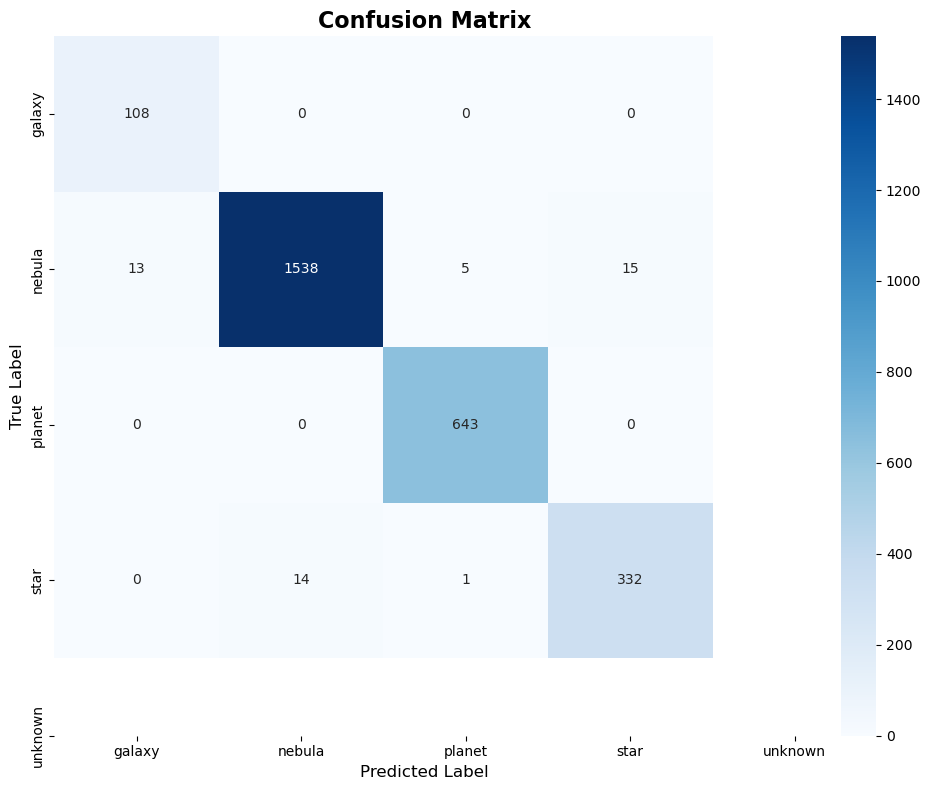

PER-CLASS ACCURACY
galaxy      : 1.0000 (100.00%) - 108 samples
nebula      : 0.9790 (97.90%) - 1571 samples
planet      : 1.0000 (100.00%) - 643 samples
unknown     : 0.9568 (95.68%) - 347 samples


In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print("PER-CLASS ACCURACY")
for i, class_name in enumerate(CLASS_NAMES):
    mask = y_test == i
    if np.sum(mask) > 0:
        class_acc = accuracy_score(y_test[mask], y_pred[mask])
        print(f"{class_name:12s}: {class_acc:.4f} ({class_acc*100:.2f}%) - {np.sum(mask)} samples")

TOP 20 MOST IMPORTANT FEATURES


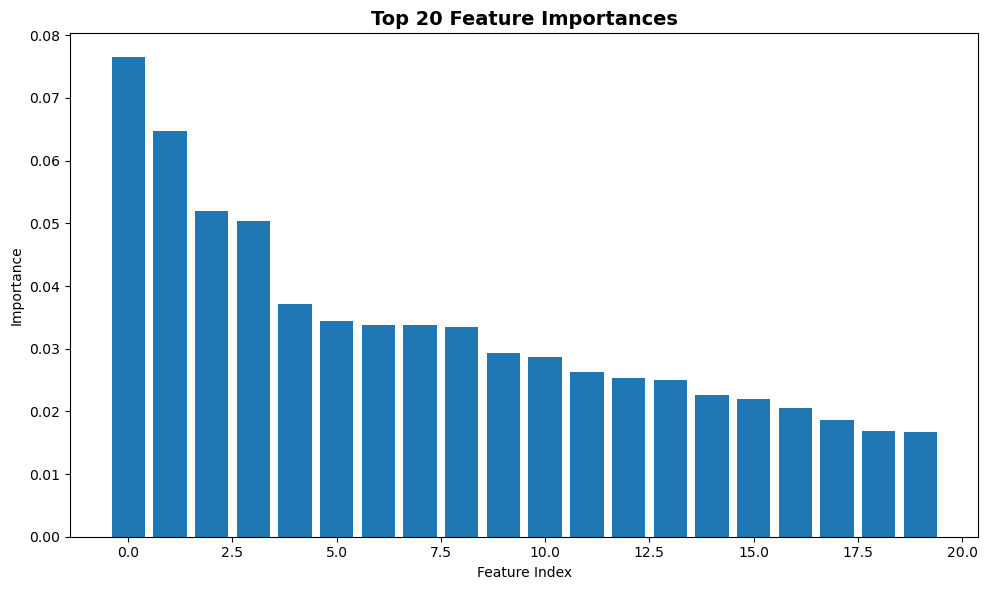


Top 10 features by importance:
  Feature 8: 0.076490
  Feature 109: 0.064741
  Feature 7: 0.051933
  Feature 0: 0.050298
  Feature 5: 0.037154
  Feature 229: 0.034349
  Feature 6: 0.033845
  Feature 192: 0.033779
  Feature 159: 0.033434
  Feature 9: 0.029370


In [21]:
if MODEL_TYPE == 'random_forest':
    print("TOP 20 MOST IMPORTANT FEATURES")
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1][:20]
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(20), importances[indices])
    plt.title('Top 20 Feature Importances', fontsize=14, fontweight='bold')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 features by importance:")
    for i in range(10):
        print(f"  Feature {indices[i]}: {importances[indices[i]]:.6f}")

In [22]:
MODEL_SAVE_PATH = 'classical_model.pkl'

model_data = {
    'model': model,
    'scaler': scaler,
    'model_type': MODEL_TYPE,
    'img_size': IMG_SIZE,
    'class_names': CLASS_NAMES
}

with open(MODEL_SAVE_PATH, 'wb') as f:
    pickle.dump(model_data, f)

print(f"Model saved to {MODEL_SAVE_PATH}")

Model saved to classical_model.pkl


In [16]:
def predict_single_image(img_path, model, scaler, class_names=CLASS_NAMES):
    """Predict the class of a single image."""
    features = extract_features(img_path)
    features_scaled = scaler.transform(features.reshape(1, -1))
    prediction = model.predict(features_scaled)[0]
    
    # Get probabilities if available
    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(features_scaled)[0]
        
        # Visualize
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        
        # Show image
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax1.imshow(img_rgb)
        ax1.axis('off')
        ax1.set_title(f'Predicted: {class_names[prediction]}', fontweight='bold')
        
        # Show probabilities
        ax2.barh(class_names, probabilities)
        ax2.set_xlabel('Probability')
        ax2.set_title('Class Probabilities')
        ax2.set_xlim([0, 1])
        
        plt.tight_layout()
        plt.show()
        
        print(f"\nPrediction: {class_names[prediction]}")
        print("\nProbabilities:")
        for name, prob in zip(class_names, probabilities):
            print(f"  {name:12s}: {prob:.4f} ({prob*100:.2f}%)")
    else:
        print(f"Prediction: {class_names[prediction]}")
    
    return class_names[prediction]

print(f"Final Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Final Test Accuracy: 0.9820 (98.20%)
